In [1]:
%load_ext autoreload
%autoreload 2

# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import sqlalchemy as sa
# Make the function folder and package root available
sys.path.append(os.path.abspath('../func/'))
sys.path.append(os.path.abspath('../../'))

NETWORK_ID = 2
FINAL_RULE_PATH = Path('outfile/1.final_variable_rules.csv')
db_url = "postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"

engine = sa.create_engine(db_url, echo=False)

In [3]:
from func_run_qc_pipeline import (
    analyze_temporal_coverage,
    build_daily_all,
    evaluate_station_quality,
    get_station_rating,
    run_qc_result_pipeline,
)
from func_network_2_variable_mapping import (
    combine_final_rule_observations, fetch_final_rule_observations,
    load_final_variable_rules, select_stations_with_final_rules,
)
from func_summary_tables import (
    create_cleaned_dataset_with_flags,
    create_flag_summary,
    create_station_evaluation_summary,
    summarize_variable_flag_rate,
)

In [4]:
final_rules = load_final_variable_rules(FINAL_RULE_PATH, NETWORK_ID)
display(final_rules)

# A station qualifies when it has at least one configured source for
# every canonical variable in final_variable_rules.csv.
df = select_stations_with_final_rules(engine, final_rules, NETWORK_ID)
print(f'Qualified stations: {len(df)}')
display(df)

,network_id,canonical_variable,source_vars_ids,time_match,overlap_method,single_source_method
0,2,air_temperature,"[434, 721]",exact_timestamp,mean,use_available
1,2,daily_max_temperature,"[433, 720]",exact_timestamp,mean,use_available
2,2,daily_min_temperature,"[435, 722]",exact_timestamp,mean,use_available
3,2,precipitation_amount,"[442, 726]",exact_timestamp,mean,use_available
4,2,snow_depth,"[450, 727]",exact_timestamp,mean,use_available
5,2,snowfall_amount,"[451, 728]",exact_timestamp,mean,use_available


Qualified stations: 168


,station_id,station_name
0,2654,Brandywine
1,2655,Tantalus
2,2657,Mt. Strachan Precip
3,2658,Mt. Strachan
4,2659,Mt. Harvey Raws
...,...,...
163,14702,NaN
164,14782,Johnson Hill
165,14854,Highline
166,14858,Galena Road


## Build daily data and run QC for each station

The following cells convert hourly data to daily, then execute the modular QC pipeline for each station.

In [5]:
stations_to_eval = df['station_id'].tolist()
stations_to_qc = stations_to_eval[50:58]

# Initialize lists to collect results across all stations
all_cleaned_with_flags = []
all_flag_summaries = []
all_station_summaries = []

# Track problematic stations
problem_station_ids = []

value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
# Fetch and combine one station at a time to keep all-network QC memory-safe.
for station_id in stations_to_qc:

    print(station_id)
    raw_station = fetch_final_rule_observations(
        engine, final_rules, [station_id]
    )
    df_station = combine_final_rule_observations(raw_station, final_rules)
    if df_station.empty:
        print(f'Skipping {station_id}: no combinable observations')
        continue

    daily_all = build_daily_all(df_station)
    result = run_qc_result_pipeline(daily_all, value_cols)

    # Generate cleaned dataset with all flags
    cleaned_with_flags = create_cleaned_dataset_with_flags(
        station_id,
        result["daily_cleaned"],
        result["naught_all"],
        result["range_results"],
        result["dup_result_dict"],
        result["ind_result_dict"],
        result["gap_result_dict"],
        result["clim_flag_df"],
        result["inttemp_tas_result"],
        result["inttemp_snow_tmin_result"],
        result["inttemp_snow_fall_dpth_result"],
        result["inttemp_snow_precip_result"],
        value_cols
    )

    all_cleaned_with_flags.append(cleaned_with_flags)

    # Generate flag summary
    flag_summary = create_flag_summary(
        cleaned_with_flags,
        station_id,
        value_cols,
        miss_result_dict=result["miss_result_dict"]
    )

    all_flag_summaries.append(flag_summary)

    flag_summary_var = summarize_variable_flag_rate(flag_summary)

    # --------------------------------------------------
    # Station evaluation
    # --------------------------------------------------
    daily_cleaned = result["daily_cleaned"]

    completeness_by_year = analyze_temporal_coverage(
        daily_cleaned,
        value_cols,
        miss_result_dict=result["miss_result_dict"]
    )

    variable_quality = evaluate_station_quality(
        daily_cleaned,
        value_cols,
        miss_result_dict=result["miss_result_dict"],
        summary_flags=flag_summary_var
    )

    # Overall station rating
    station_rating, recommendation = get_station_rating(
        [q["rating"] for q in variable_quality.values()]
    )

    print(station_rating)
    print(recommendation)

    # Record problematic stations
    if station_rating != "✅ GOOD QUALITY":
        problem_station_ids.append(station_id)

    # --------------------------------------------------
    # Generate station evaluation summary
    # --------------------------------------------------
    station_summary = create_station_evaluation_summary(
        daily_cleaned,
        station_id,
        completeness_by_year,
        variable_quality,
        station_rating,
        recommendation,
        value_cols
    )

    all_station_summaries.append(station_summary)

# Combine all results into flat tables
cleaned_data_master = pd.concat(all_cleaned_with_flags, ignore_index=True)
flag_summary_master = pd.concat(all_flag_summaries, ignore_index=True)
station_summary_master = pd.concat(all_station_summaries, ignore_index=True)

2789
STATION QUALITY EVALUATION SUMMARY (QC SCORING ENGINE)

VARIABLE-BY-VARIABLE QUALITY ASSESSMENT
--------------------------------------------------------------------------------

✅ TEMP         GOOD        
   Missing rate:   8.22%
   Flag rate:      0.05%
   Large gaps:   NO

⚠️⚠️ TMIN         PROBLEMATIC 
   Missing rate:  36.75%
   Flag rate:      0.01%
   Large gaps:   YES
   ⚠️ Missing rate 36.7%
   ⚠️ Large temporal gap > 1 year

⚠️⚠️ TMAX         PROBLEMATIC 
   Missing rate:  36.61%
   Flag rate:      0.04%
   Large gaps:   YES
   ⚠️ Missing rate 36.6%
   ⚠️ Large temporal gap > 1 year

✅ PRECIP       GOOD        
   Missing rate:  16.83%
   Flag rate:      0.57%
   Large gaps:   NO

⚠️ SNW_FALL     CAUTION     
   Missing rate:   2.41%
   Flag rate:      1.97%
   Large gaps:   YES
   ⚠️ Large temporal gap > 1 year

✅ SNW_DPTH     GOOD        
   Missing rate:   2.84%
   Flag rate:      0.47%
   Large gaps:   NO

SUMMARY:
  ✅ GOOD        : 3
  ⚠️ CAUTION     : 1
  ⚠️⚠️ PROB

## Export Summary Tables to CSV

Save the generated summary tables to CSV files for external analysis and reporting.

In [6]:
# Create output directory if it doesn't exist
output_dir = Path(
    '/workspaces/crmprtd/Quanlity_Control/pipeline/network_2/outfile')
output_dir.mkdir(parents=True, exist_ok=True)

# Save the three summary tables to CSV
cleaned_data_file = output_dir / '2.cleaned_data_with_flags.csv'
flag_summary_file = output_dir / '3.flag_summary.csv'
station_summary_file = output_dir / '4.station_evaluation_summary.csv'

cleaned_data_master.to_csv(cleaned_data_file, index=False)
flag_summary_master.to_csv(flag_summary_file, index=False)
station_summary_master.to_csv(station_summary_file, index=False)

print(f"✅ CSV files saved successfully!\n")
print(f"1. Cleaned data with flags: {cleaned_data_file}")
print(f"   Shape: {cleaned_data_master.shape}\n")
print(f"2. Flag summary: {flag_summary_file}")
print(f"   Shape: {flag_summary_master.shape}\n")
print(f"3. Station evaluation summary: {station_summary_file}")
print(f"   Shape: {station_summary_master.shape}")

✅ CSV files saved successfully!

1. Cleaned data with flags: /workspaces/crmprtd/Quanlity_Control/pipeline/network_2/outfile/2.cleaned_data_with_flags.csv
   Shape: (70904, 69)

2. Flag summary: /workspaces/crmprtd/Quanlity_Control/pipeline/network_2/outfile/3.flag_summary.csv
   Shape: (544, 5)

3. Station evaluation summary: /workspaces/crmprtd/Quanlity_Control/pipeline/network_2/outfile/4.station_evaluation_summary.csv
   Shape: (56, 10)


## Compare time series before and after cleaning

The left column shows the original hourly observations and the right column shows the cleaned daily series with its variable-quality rating. Each panel uses its own y-axis scale. Change `PLOT_STATION_ID` to inspect another station included in `stations_to_qc`.

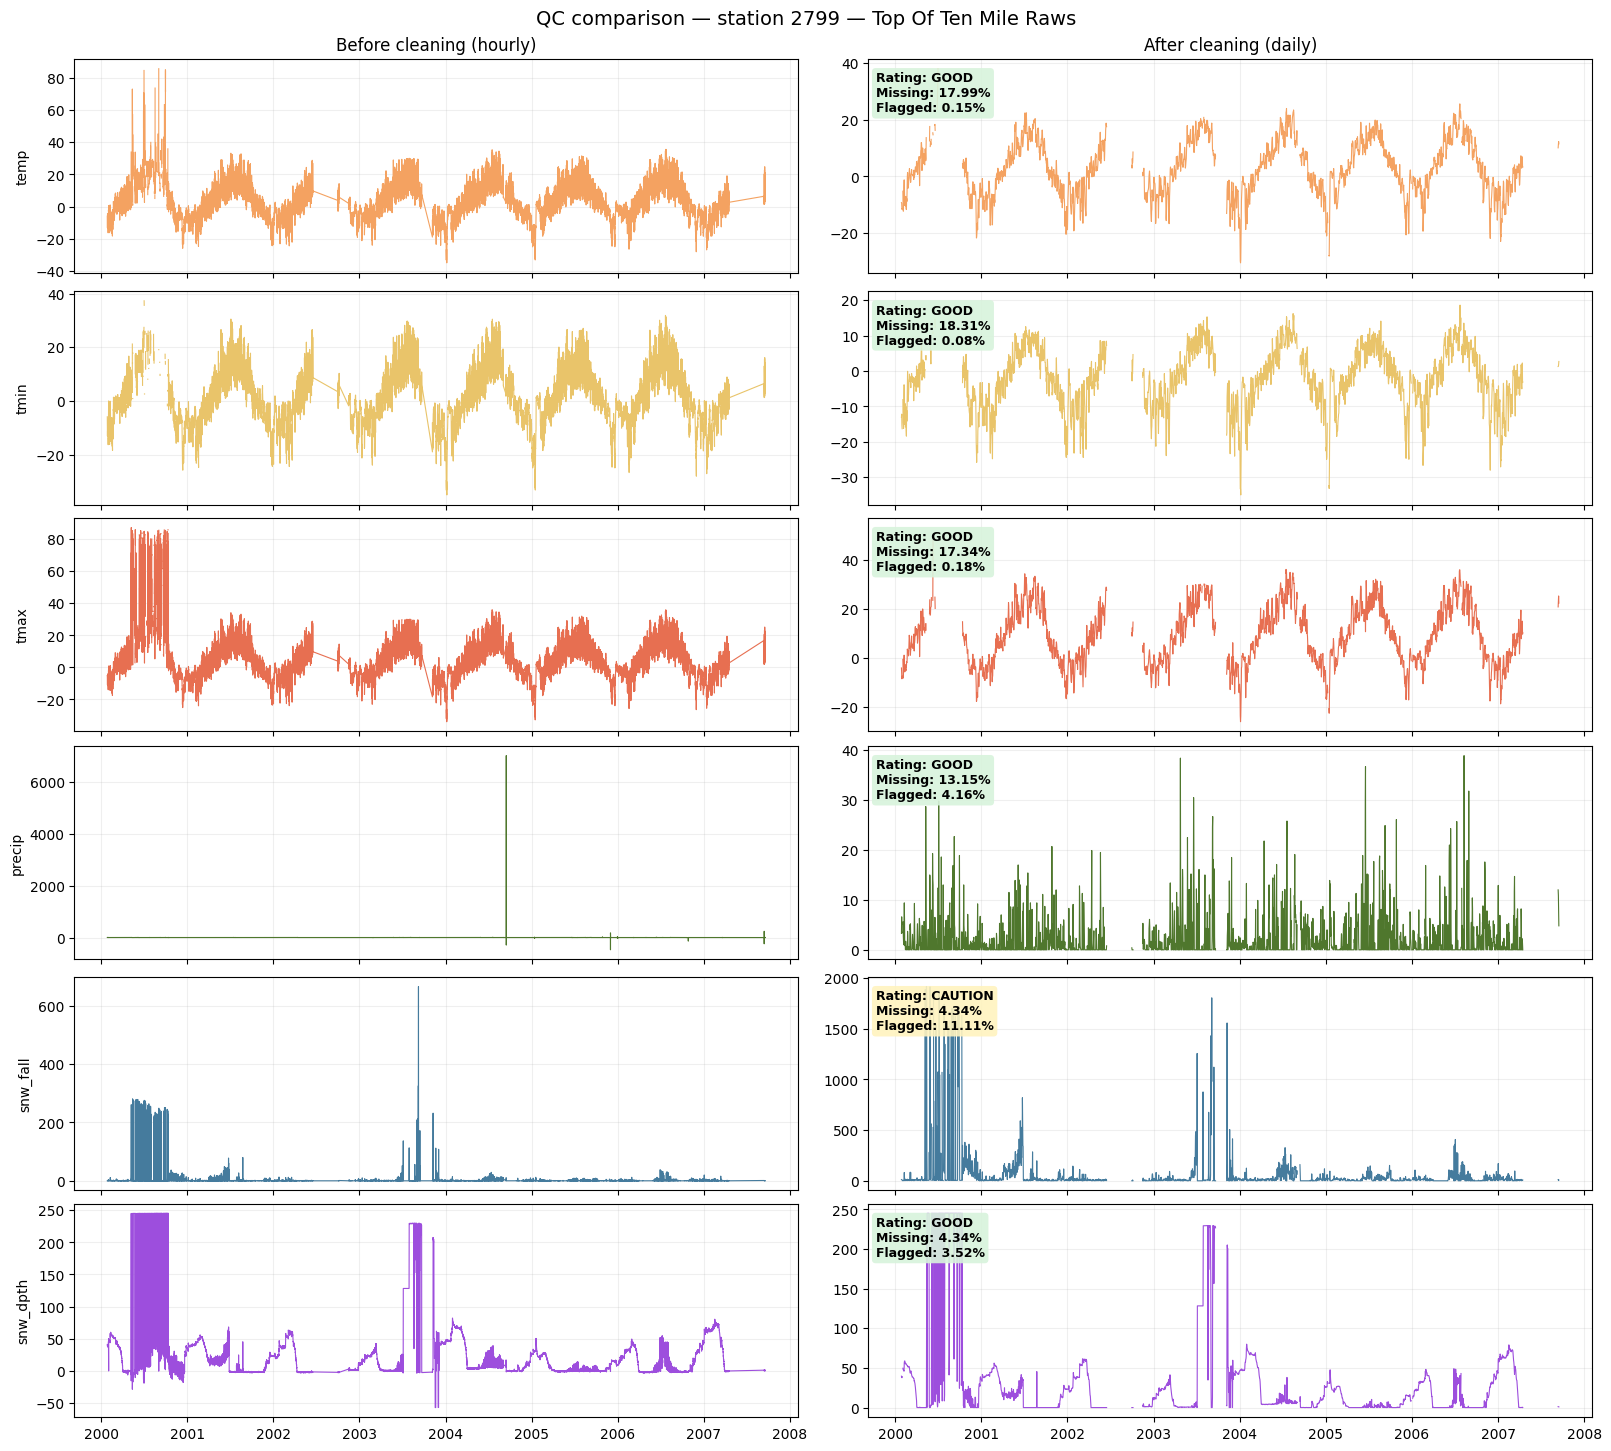

In [8]:
import matplotlib.pyplot as plt

weather_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
PLOT_STATION_ID = 2799  # stations_to_qc[3]

# Build the original hourly series before daily aggregation or QC.
plot_obs_raw = fetch_final_rule_observations(
    engine, final_rules, [PLOT_STATION_ID]
)
plot_obs = combine_final_rule_observations(plot_obs_raw, final_rules)
station_name = df.loc[
    df["station_id"] == PLOT_STATION_ID, "station_name"
].iloc[0]
plot_obs["obs_time"] = pd.to_datetime(plot_obs["obs_time"])
before_qc = (
    plot_obs.pivot_table(
        index="obs_time",
        columns="net_var_name",
        values="datum",
    )
    .sort_index()
    .reindex(columns=weather_cols)
)

# Select by station ID so the before/after series always refer to the same station.
after_qc = (
    cleaned_data_master.loc[
        cleaned_data_master["station_id"] == PLOT_STATION_ID,
        ["date", *weather_cols],
    ]
    .assign(date=lambda data: pd.to_datetime(data["date"]))
    .set_index("date")
    .sort_index()
)
variable_quality_metrics = (
    station_summary_master.loc[
        (station_summary_master["station_id"] == PLOT_STATION_ID)
        & station_summary_master["variable"].isin(weather_cols),
        ["variable", "rating", "missing_rate_pct", "flag_rate_pct"],
    ]
    .drop_duplicates(subset="variable")
    .set_index("variable")
    .to_dict(orient="index")
)

if before_qc.empty or after_qc.empty:
    raise ValueError(
        f"No before/after data found for station {PLOT_STATION_ID}")

color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "precip": "#4f772d",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
}
rating_colors = {
    "GOOD": "#d8f3dc",
    "CAUTION": "#fff3bf",
    "UNRELIABLE": "#ffd8a8",
    "PROBLEMATIC": "#ffc9c9",
    "UNUSABLE": "#ff8787",
    "UNKNOWN": "#e9ecef",
}

fig, axes = plt.subplots(
    len(weather_cols), 2,
    figsize=(16, 2.4 * len(weather_cols)),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)

for row, variable in enumerate(weather_cols):
    color = color_map[variable]
    axes[row, 0].plot(before_qc.index, before_qc[variable],
                      color=color, lw=0.8)
    axes[row, 1].plot(after_qc.index, after_qc[variable], color=color, lw=0.8)
    axes[row, 0].set_ylabel(variable)
    axes[row, 0].grid(alpha=0.2)
    axes[row, 1].grid(alpha=0.2)

    quality = variable_quality_metrics.get(variable, {})
    rating = quality.get("rating", "UNKNOWN")
    missing_rate = quality.get("missing_rate_pct", np.nan)
    flag_rate = quality.get("flag_rate_pct", np.nan)
    missing_label = f"{missing_rate:.2f}%" if pd.notna(missing_rate) else "N/A"
    flag_label = f"{flag_rate:.2f}%" if pd.notna(flag_rate) else "N/A"
    axes[row, 1].text(
        0.01, 0.94,
        f"Rating: {rating}\nMissing: {missing_label}\nFlagged: {flag_label}",
        transform=axes[row, 1].transAxes,
        va="top",
        fontsize=9,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": rating_colors.get(rating, rating_colors["UNKNOWN"]),
            "edgecolor": "none",
            "alpha": 0.9,
        },
    )

axes[0, 0].set_title("Before cleaning (hourly)")
axes[0, 1].set_title("After cleaning (daily)")
fig.suptitle(
    f"QC comparison — station {PLOT_STATION_ID} — {station_name}",
    fontsize=14,
)
plt.show()